# Model 1B — P(P_rot | log_mass, log_σ_mass_lo, log_σ_mass_hi, log_age)

**Variant 1B**: inverse age uncertainty loss weighting — stars with tighter age constraints contribute more to the loss.

Flow x (density variable): `log_prot`  
Conditioning vector: `[log_age_myr, log_mass_msun, log_mass_err_lo, log_mass_err_hi]`  
Loss: `loss = −mean(logsumexp(W_F · w_age_i · ln p_flow_i, ln p_bg))` where `w_age_i = (1/(err_lo + err_hi)) / mean(1/(err_lo + err_hi))` with age uncertainties in Gyr.

Training set: 5846 stars (273 with missing age uncertainty dropped — required for loss weighting).  
At inference: identical to 1A — fix observed (log_prot, log_mass, log_σ_mass), sweep log_age → posterior P(age | prot, mass, σ_mass).

In [1]:
import sys
sys.path.insert(0, '../..')

import numpy as np
import pandas as pd
import torch
import pickle
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams['figure.dpi'] = 120

from training.constants import LOGA_GRID
from training.data     import load_training
from training.kfold    import run_kfold
from training.infer    import batch_posteriors
from training.metrics  import compute_residuals
from training.report   import training_report, kfold_report, posterior_report, prot_space_report

## 1. Load data

In [2]:
df = load_training('../../cf_data/training_stars.csv', drop_nan_age_err=True)
print(f'Total stars: {len(df)}')
print(f'Clusters: {df["source_paper"].nunique()}')
df[['log_prot', 'log_age_myr', 'log_mass_msun', 'log_mass_err_lo', 'log_mass_err_hi']].describe()

Total stars: 5846
Clusters: 20


,log_prot,log_age_myr,log_mass_msun,log_mass_err_lo,log_mass_err_hi
count,5846.000000,5846.000000,5846.000000,5846.000000,5846.000000
mean,0.276234,2.128005,-0.377199,-1.840845,-1.838215
std,0.571320,0.654343,0.167650,0.246192,0.235414
min,-1.084073,0.176091,-1.008407,-2.624122,-2.617476
25%,-0.152376,1.653213,-0.479014,-1.996526,-1.987311
50%,0.186679,2.123852,-0.332310,-1.864209,-1.856940
75%,0.656998,2.599883,-0.241529,-1.763098,-1.755619
max,2.241546,4.060698,-0.171430,-1.039938,-1.097869


## 2. Define conditioning columns

In [3]:
OBS_COL   = 'log_prot'
COND_COLS = ['log_age_myr', 'log_mass_msun', 'log_mass_err_lo', 'log_mass_err_hi']
N_FOLDS   = 5
STEPS     = 5000

print('Conditioning vector size:', len(COND_COLS))
print('Columns:', COND_COLS)

Conditioning vector size: 4
Columns: ['log_age_myr', 'log_mass_msun', 'log_mass_err_lo', 'log_mass_err_hi']


## 3. K-fold training

In [4]:
import importlib, training.kfold
importlib.reload(training.kfold)
from training.kfold import run_kfold

results_df, fold_flows, fold_scalers, loss_curves, posteriors_kfold = run_kfold(
    df          = df,
    obs_col     = OBS_COL,
    cond_cols   = COND_COLS,
    n_folds     = N_FOLDS,
    steps       = STEPS,
    age_weights = True,
)


=== Fold 1 / 5 ===
step     0  loss 0.814187
step  1000  loss -0.041039
step  2000  loss -0.077561
step  3000  loss -0.090406
step  4000  loss -0.092387
step  5000  loss -0.093295

=== Fold 2 / 5 ===
step     0  loss 1.061444
step  1000  loss -0.024748
step  2000  loss -0.050413
step  3000  loss -0.060174
step  4000  loss -0.061536
step  5000  loss -0.062185

=== Fold 3 / 5 ===
step     0  loss 1.054243
step  1000  loss -0.025051
step  2000  loss -0.056125
step  3000  loss -0.068404
step  4000  loss -0.070164
step  5000  loss -0.071000

=== Fold 4 / 5 ===
step     0  loss 1.061396
step  1000  loss -0.039326
step  2000  loss -0.066481
step  3000  loss -0.077778
step  4000  loss -0.079580
step  5000  loss -0.080403

=== Fold 5 / 5 ===
step     0  loss 1.050332
step  1000  loss -0.032154
step  2000  loss -0.063587
step  3000  loss -0.078620
step  4000  loss -0.080809
step  5000  loss -0.081797


## 4. Training loss

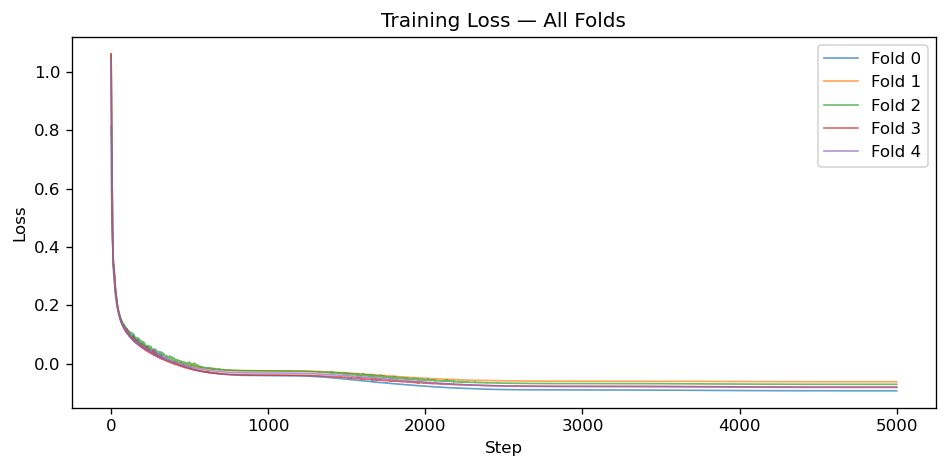

In [5]:
training_report(loss_curves)

## 5. Residual diagnostics

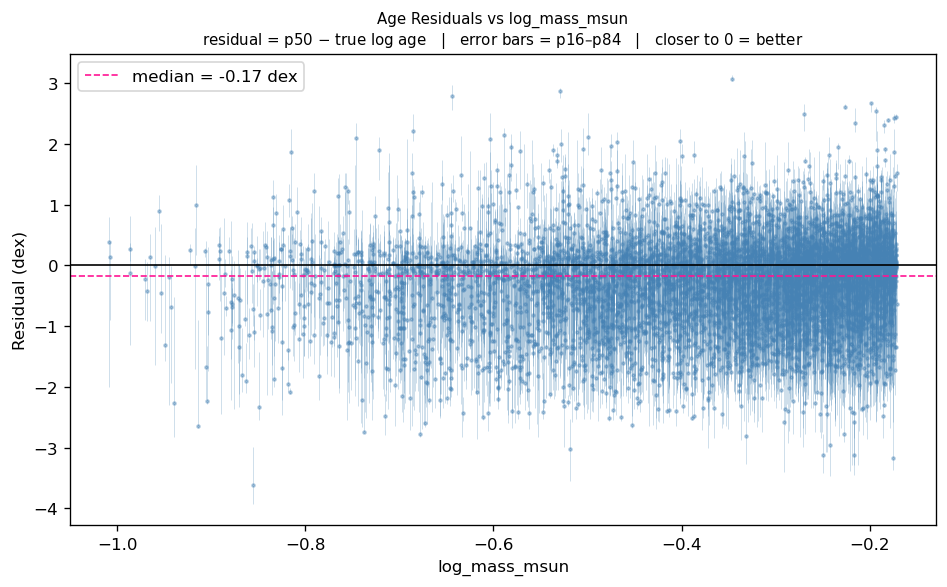

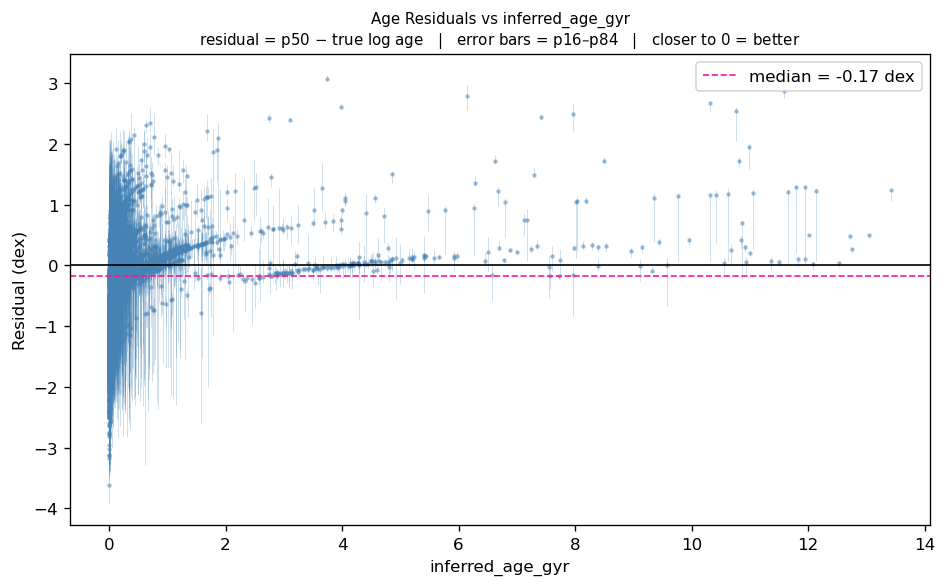

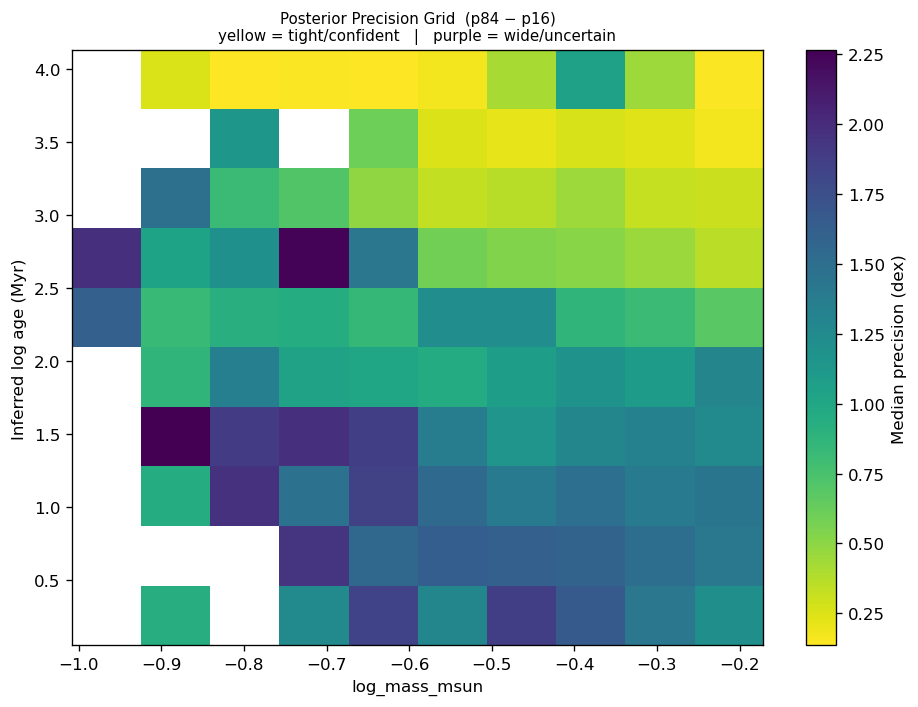

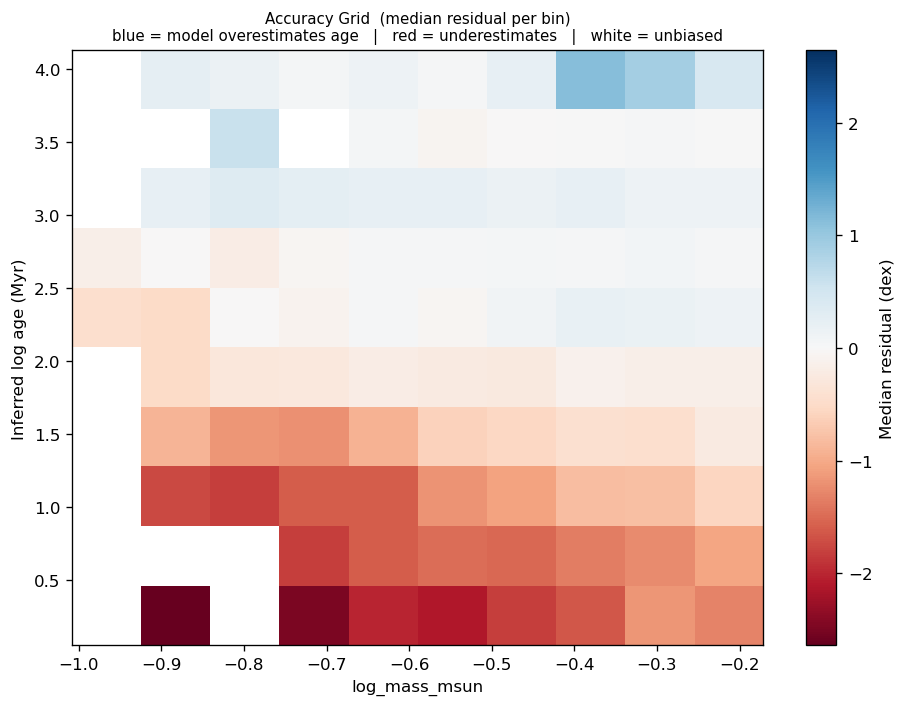

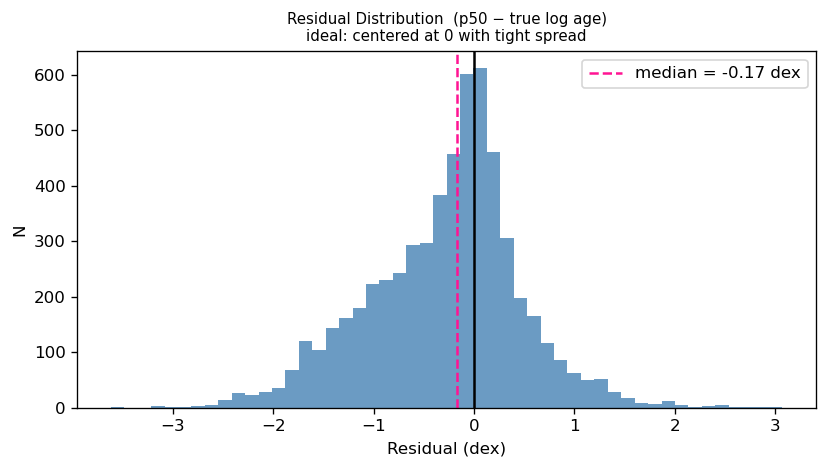

In [6]:
import importlib
import training.plots, training.report
importlib.reload(training.plots)
importlib.reload(training.report)
from training.report import kfold_report

kfold_report(results_df, x_col='log_mass_msun')

## 6. Held-out posteriors (each star evaluated on its val fold)

Posteriors shape: (5846, 1000)


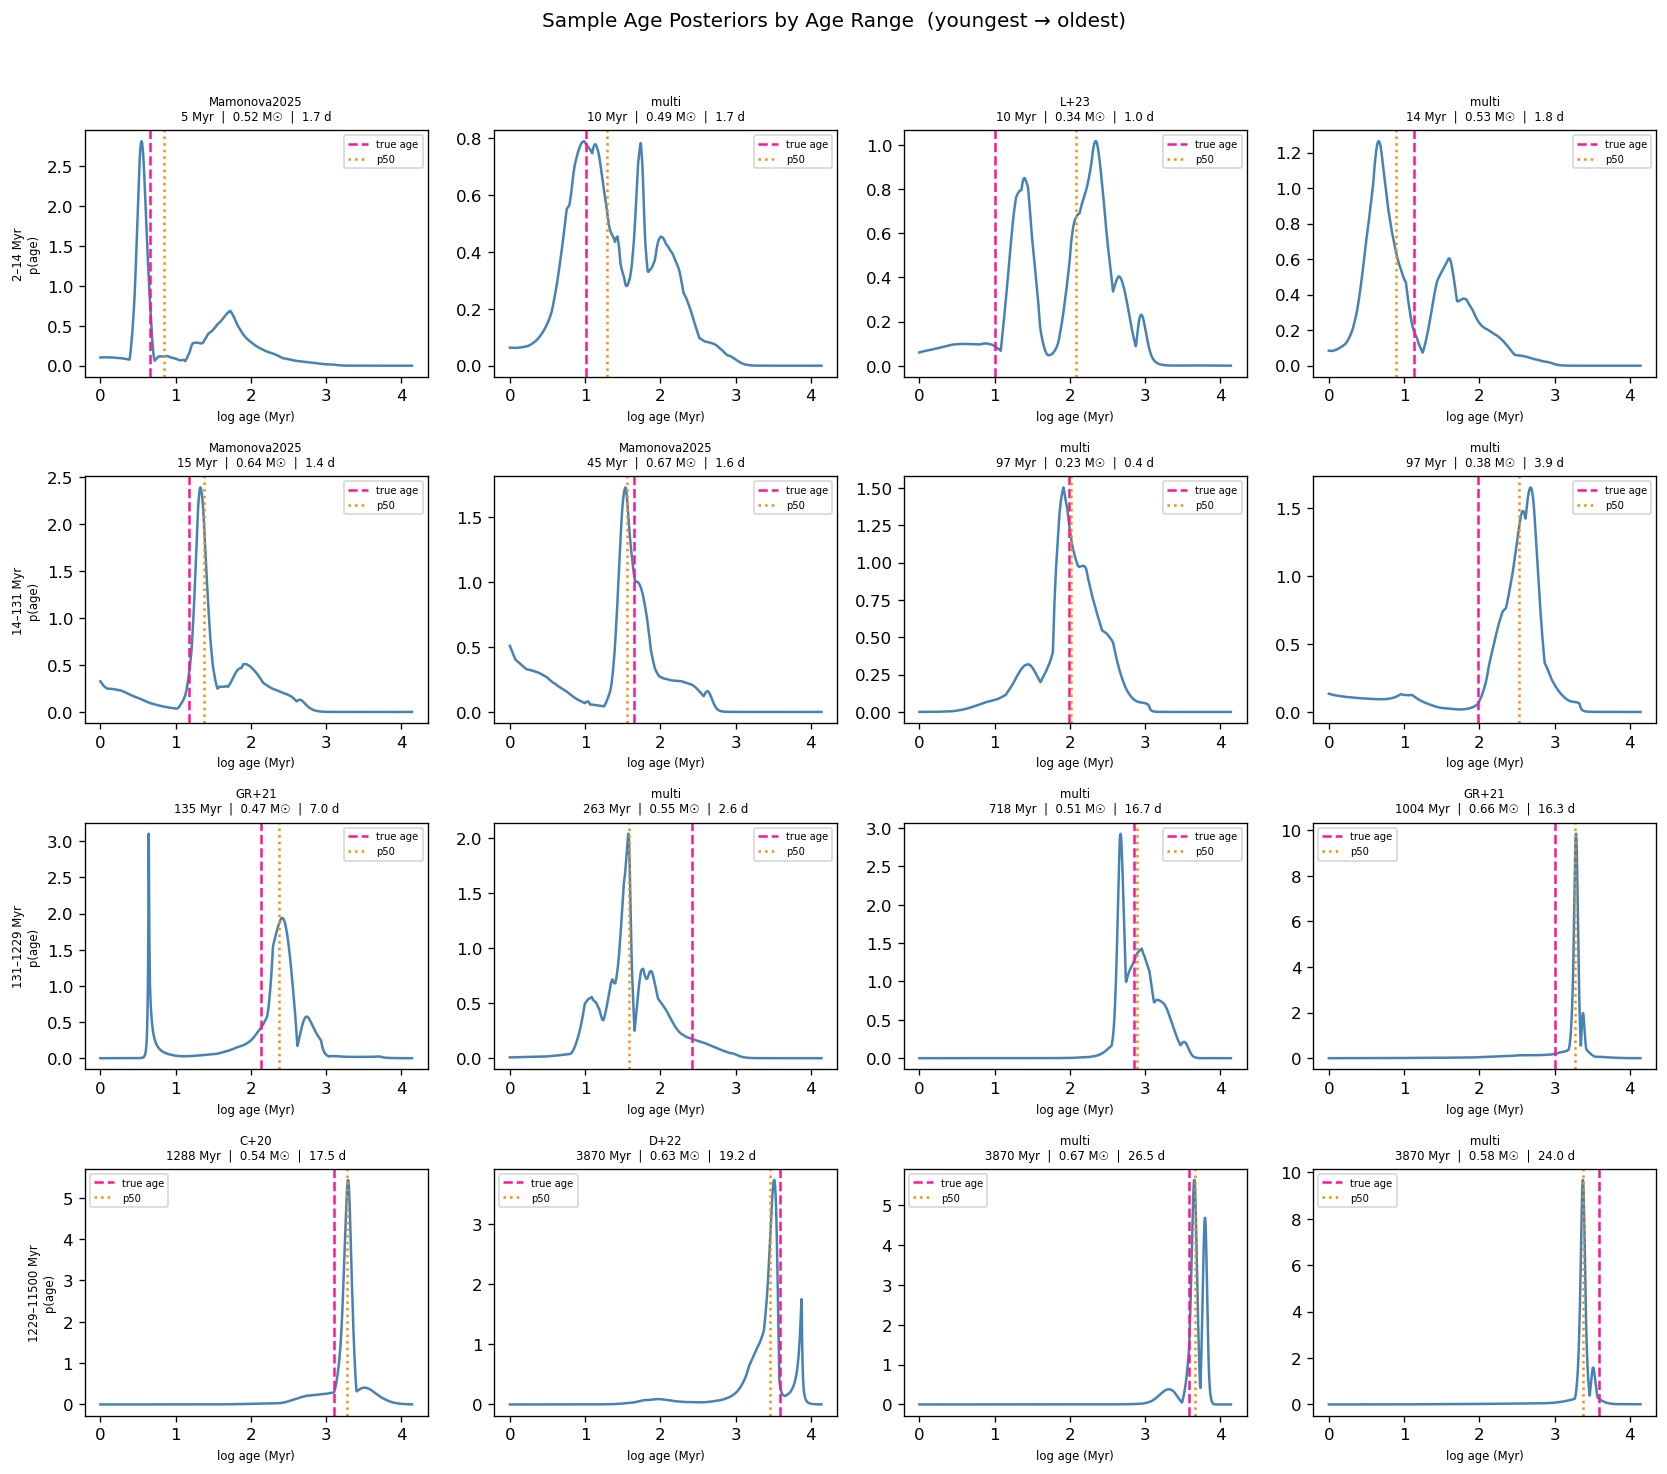

In [7]:
import importlib
import training.plots, training.report
importlib.reload(training.plots)
importlib.reload(training.report)
from training.plots import plot_posteriors_by_age

print('Posteriors shape:', posteriors_kfold.shape)
plot_posteriors_by_age(posteriors_kfold, LOGA_GRID, results_df, n_rows=4, n_cols=4)

## 6b. Posteriors near the fully convective boundary (0.3–0.4 M☉)

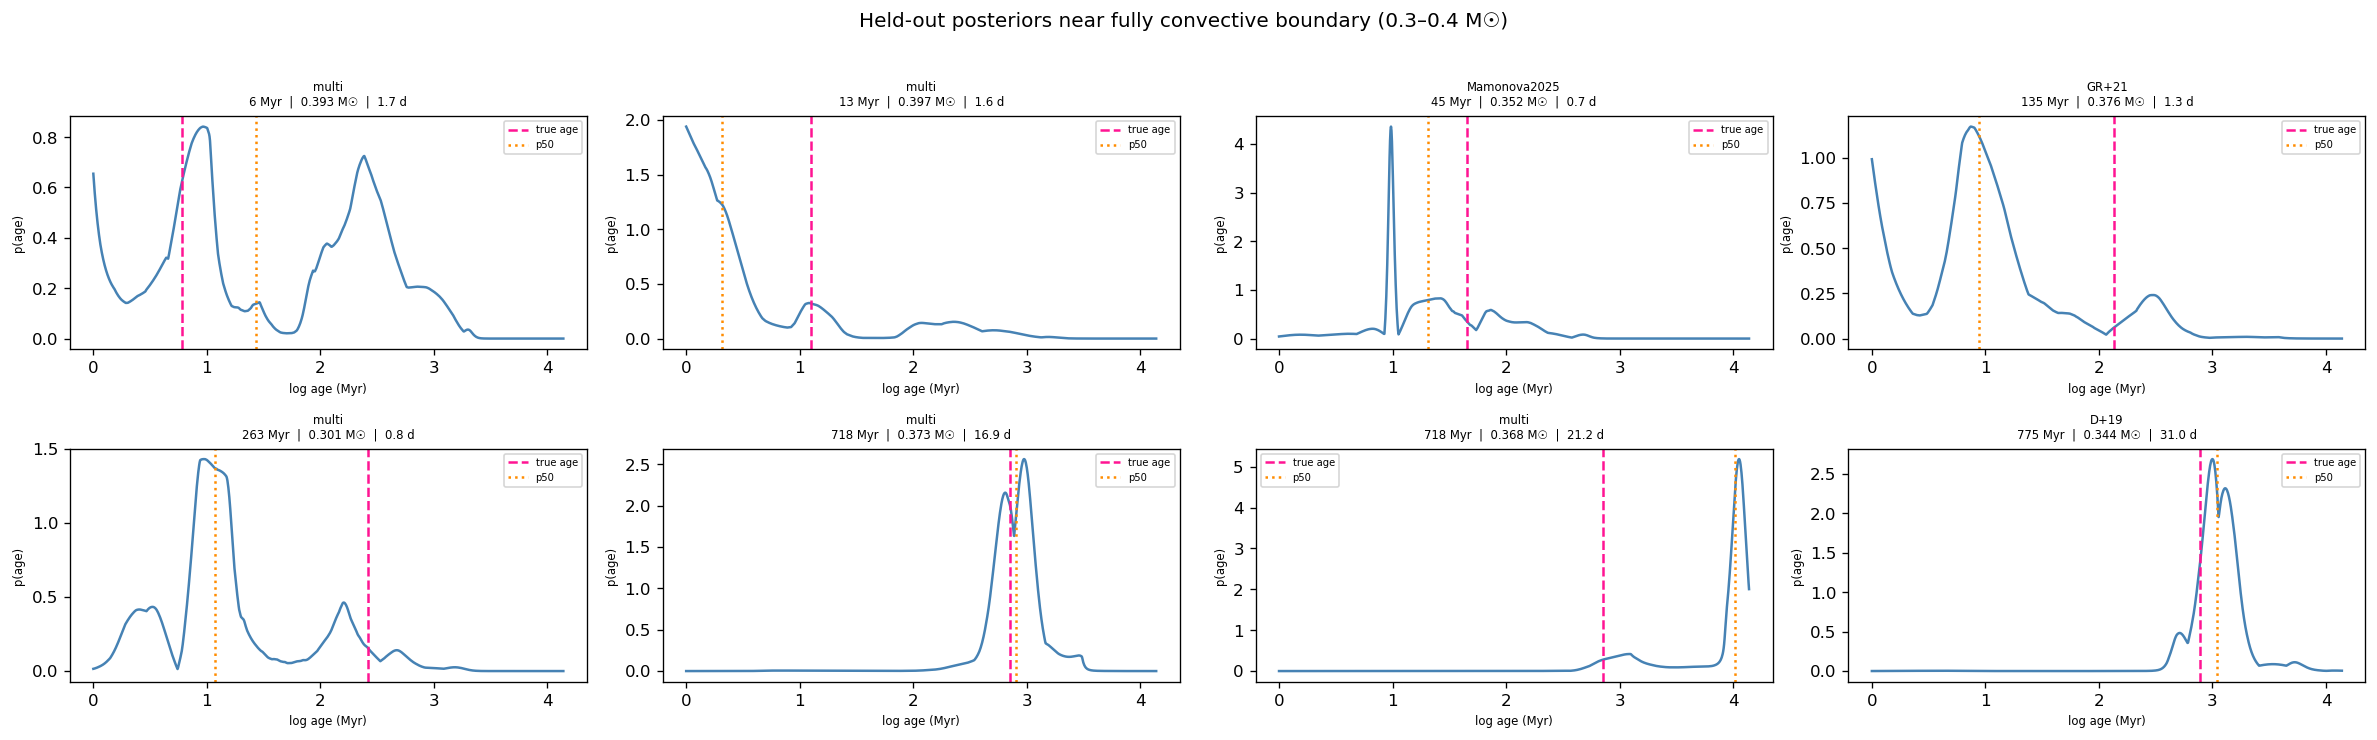

In [8]:
_field = {'MOCADB', 'Engle2023', 'LWRD', 'Pass2022'}
fc_mask = (results_df['mass_msun'] >= 0.3) & (results_df['mass_msun'] <= 0.4)
fc_df   = results_df[fc_mask].copy().reset_index(drop=True)
fc_pos  = np.where(fc_mask)[0]

is_cluster = ~fc_df['source_paper'].isin(_field)
pool_idx   = np.where(is_cluster)[0] if is_cluster.sum() >= 8 else np.arange(len(fc_df))
age_order  = pool_idx[np.argsort(fc_df.iloc[pool_idx]['log_age_myr'].values)]
pick       = age_order[np.linspace(0, len(age_order) - 1, 8, dtype=int)]

n_cols = 4
n_rows = 2
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 6))
axes = axes.flatten()
for ax, i in zip(axes, pick):
    row      = fc_df.iloc[i]
    post_idx = fc_pos[i]
    ax.plot(LOGA_GRID, posteriors_kfold[post_idx], color='steelblue', lw=1.5)
    ax.axvline(row['log_age_myr'], color='deeppink', lw=1.5, ls='--', label='true age')
    ax.axvline(row['p50'], color='darkorange', lw=1.5, ls=':', label='p50')
    ax.set_title(f"{row['source_paper']}\n{10**row['log_age_myr']:.0f} Myr  |  {row['mass_msun']:.3f} M☉  |  {row['prot_days']:.1f} d", fontsize=7)
    ax.set_xlabel('log age (Myr)', fontsize=7)
    ax.set_ylabel('p(age)', fontsize=7)
    ax.legend(fontsize=6)
plt.suptitle('Held-out posteriors near fully convective boundary (0.3–0.4 M☉)', y=1.02)
plt.tight_layout()
plt.show()

## 7. P(P_rot | age, mass) heatmap per cluster

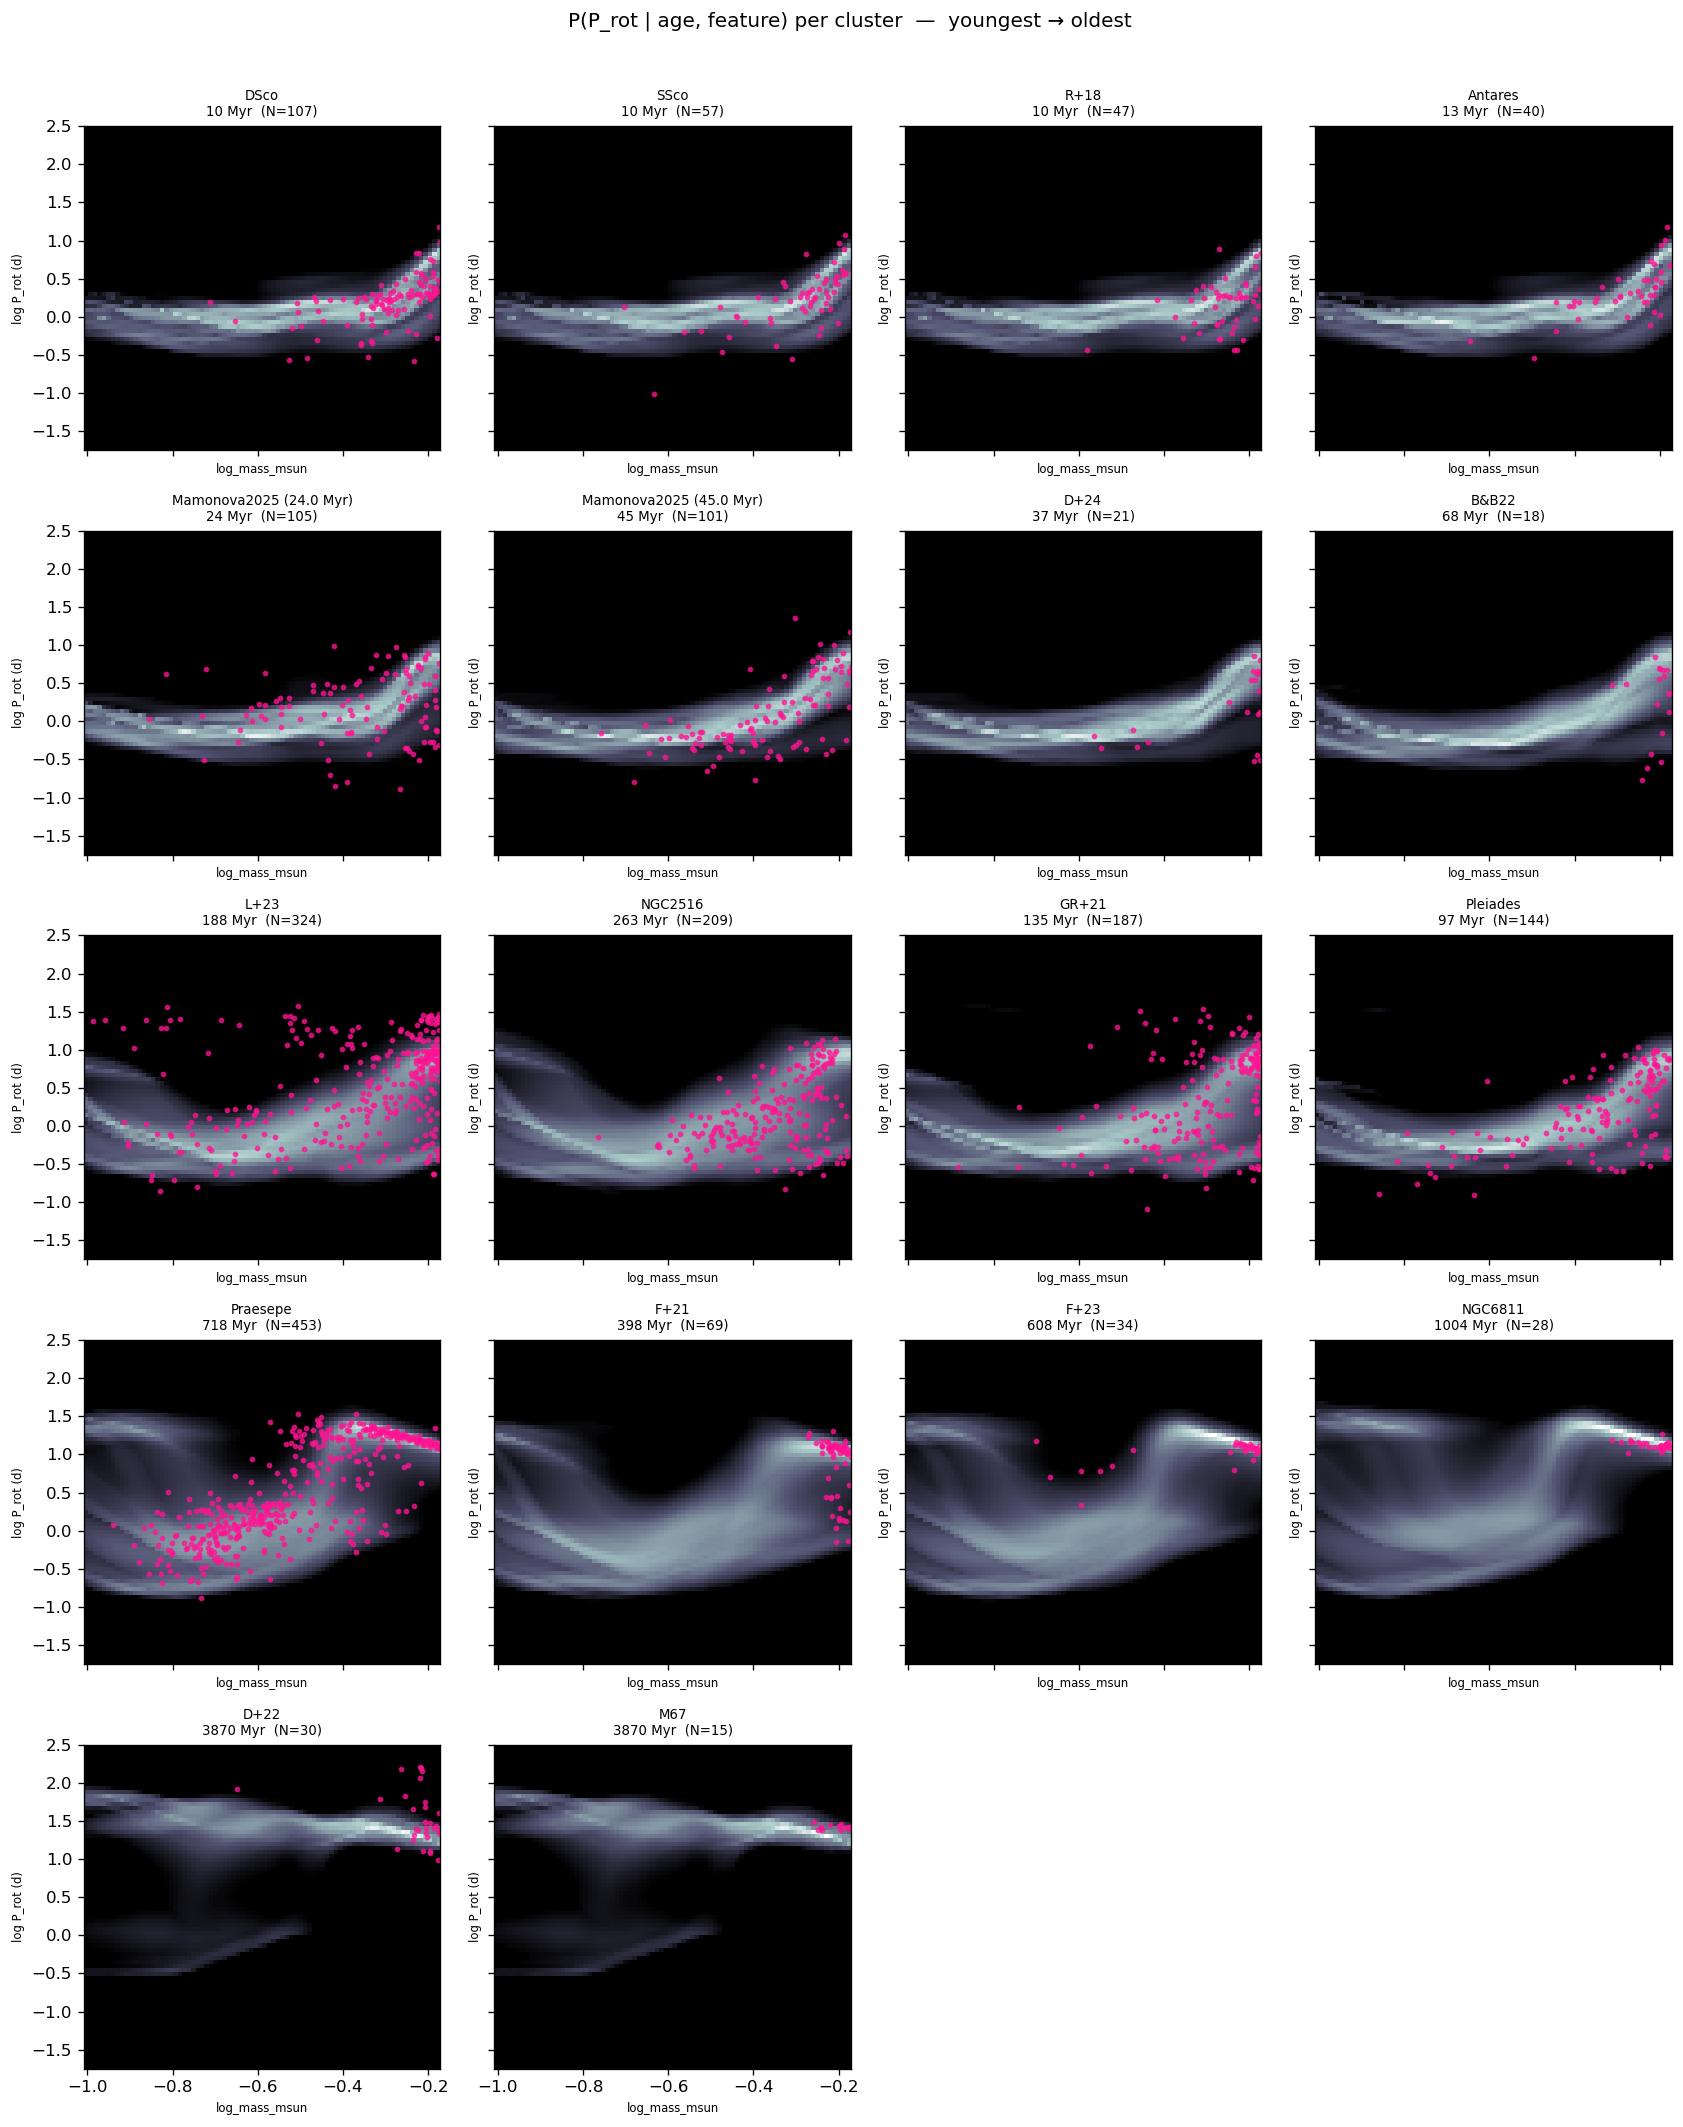

In [9]:
import importlib
import training.data, training.plots, training.report
importlib.reload(training.data)
importlib.reload(training.plots)
importlib.reload(training.report)
from training.data   import load_training
from training.report import prot_space_report

df = load_training('../../cf_data/training_stars.csv', drop_nan_age_err=True)
prot_space_report(fold_flows, df, COND_COLS, fold_scalers)

## 8. Summary statistics

In [10]:
print('=== 1B Mass — K-fold validation summary ===')
print(f'N stars evaluated : {len(results_df)}')
print(f'Median residual   : {results_df["residual_dex"].median():.3f} dex')
print(f'Median precision  : {(results_df["p84"] - results_df["p16"]).median():.3f} dex')
print(f'% within 0.3 dex  : {(results_df["residual_dex"].abs() < 0.3).mean()*100:.1f}%')
results_df.groupby('fold')[['residual_dex']].agg(['median', 'std'])

=== 1B Mass — K-fold validation summary ===
N stars evaluated : 5846
Median residual   : -0.170 dex
Median precision  : 1.140 dex
% within 0.3 dex  : 39.5%


residual_dex          
           median       std
fold                       
0       -0.180864  0.780623
1       -0.140672  0.788343
2       -0.213389  0.730725
3       -0.141459  0.722764
4       -0.177149  0.770695

## 9. Save models and results

In [11]:
import os
os.makedirs('../../outputs/1b_mass_p05', exist_ok=True)

results_df.to_csv('../../outputs/1b_mass_p05/results.csv', index=False)
np.save('../../outputs/1b_mass_p05/posteriors_kfold.npy', posteriors_kfold)
np.save('../../outputs/1b_mass_p05/loss_curves.npy', np.array(loss_curves, dtype=object), allow_pickle=True)

for i, (flow, scaler) in enumerate(zip(fold_flows, fold_scalers)):
    torch.save(flow.state_dict(), f'../../outputs/1b_mass_p05/fold{i}_flow.pt')
    with open(f'../../outputs/1b_mass_p05/fold{i}_scaler.pkl', 'wb') as f:
        pickle.dump(scaler, f)

print('Saved to outputs/1b_mass_p05/')

Saved to outputs/1b_mass_p05/


## 10. 68% coverage calibration check

A calibrated 68% age interval should contain the true age for about 68% of held-out stars.

In [12]:
valid = results_df[['log_age_myr', 'p16', 'p84']].notna().all(axis=1)
inside_68 = (
    valid
    & (results_df['log_age_myr'] >= results_df['p16'])
    & (results_df['log_age_myr'] <= results_df['p84'])
)

n = int(valid.sum())
cover68 = inside_68[valid].mean()
expected = 0.68
binom_sigma = np.sqrt(expected * (1 - expected) / n)
offset_sigma = (cover68 - expected) / binom_sigma

print('=== 68% posterior coverage check ===')
print(f'N valid stars       : {n}')
print(f'Observed coverage   : {cover68:.3f} ({cover68*100:.1f}%)')
print(f'Expected coverage   : {expected:.3f} +/- {binom_sigma:.3f} (binomial 1-sigma)')
print(f'Coverage offset     : {offset_sigma:+.2f} sigma')

if cover68 < expected - binom_sigma:
    print('Interpretation      : under-covering; posteriors are likely too narrow / overconfident.')
elif cover68 > expected + binom_sigma:
    print('Interpretation      : over-covering; posteriors are likely too broad / conservative.')
else:
    print('Interpretation      : close to nominal 68% calibration.')

coverage_by_fold = (
    results_df.loc[valid]
    .assign(inside_68=inside_68[valid].to_numpy())
    .groupby('fold')['inside_68']
    .agg(cover68='mean', n='size')
)
coverage_by_fold

=== 68% posterior coverage check ===
N valid stars       : 5846
Observed coverage   : 0.600 (60.0%)
Expected coverage   : 0.680 +/- 0.006 (binomial 1-sigma)
Coverage offset     : -13.07 sigma
Interpretation      : under-covering; posteriors are likely too narrow / overconfident.


,cover68,n
fold,,
0,0.580342,1170
1,0.579127,1169
2,0.633875,1169
3,0.616766,1169
4,0.591104,1169
